TP2 Classification automatique de textes
Valentin MASSONNIERE - solo

Identifier un cas d’usage de votre choix pour appliquer le NLP et implémenter
un modèle de classification afin d’analyser les données textuelles, évaluer sa
performance et interpréter les résultats.

J'ai décidé de partir sur le dataset 'Amazon reviews' : https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews?resource=download
Il regroupe 34 686 770 commentaires de 6 643 669 utilisateurs sur 2 441 053 produits.
Dans mon cas, je limiterais les commentaires positifs et négatifs à 10 000 chacuns.

Choisir le modèle que vous souhaitez utiliser pour votre étude de cas, et vous
assurer de bien comprendre les raisons qui motivent ce choix.

Pour ce cas d'étude, j'ai choisi d'utiliser l'algorithme SVM. Avec ce tutoriel : https://www.kaggle.com/code/mehmetlaudatekman/text-classification-svm-explained

Trouver un jeu de données disponible en ligne adapté à votre étude, l’explorer,
le nettoyer et le préparer si nécessaire.

In [1]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
import re

Ici j'importe le dataset d'entraînement et de tests et j'associe des noms de colonnes

In [4]:
train_set = pd.read_csv('data/train.csv',encoding="latin1", header=None)
test_set = pd.read_csv('data/test.csv',encoding="latin1", header=None)

train_set.columns = ['note', 'subject', 'review']
test_set.columns = ['note', 'subject', 'review']

train_set.head()

,note,subject,review
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


Je retire la colonne qui représente le sujet du commentaire.

In [5]:
unrelevant_features = ["subject"]

train_set.drop(unrelevant_features,inplace=True,axis=1)
test_set.drop(unrelevant_features,inplace=True,axis=1)
train_set.head()

,note,review
0,2,This sound track was beautiful! It paints the ...
1,2,I'm reading a lot of reviews saying that this ...
2,2,This soundtrack is my favorite music of all ti...
3,2,I truly like this soundtrack and I enjoy video...
4,2,"If you've played the game, you know how divine..."


In [6]:
train_set["note"].value_counts()

note
2    1800000
1    1800000
Name: count, dtype: int64

Je créer 2 tableaux pour le dataset d'entraînement et de test qui sépare les commantaires positives et négatives. 1 est considérer comme négatif et 2 comme positif. Je remplace ces valeurs pour 0 comme négatif et positif à 1.

In [7]:
positives = train_set[(train_set["note"] == 2)]
positives_test = test_set[(test_set["note"] == 2)]
positives["note"] = 1
positives_test["note"] = 1
print(positives["note"].value_counts())
print(positives_test["note"].value_counts())
# positives.head()
# positives_test.head()

negatives = train_set[(train_set["note"] == 1)]
negatives_test = test_set[(test_set["note"] == 1)]
negatives["note"] = 0 
negatives_test["note"] = 0
print(negatives["note"].value_counts())
print(negatives_test["note"].value_counts())
# negatives.head()
# negatives_test.head()


note
1    1800000
Name: count, dtype: int64
note
1    200000
Name: count, dtype: int64
note
0    1800000
Name: count, dtype: int64
note
0    200000
Name: count, dtype: int64


C:\Users\Valentin\AppData\Local\Temp\ipykernel_14764\1200913812.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positives["note"] = 1
C:\Users\Valentin\AppData\Local\Temp\ipykernel_14764\1200913812.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positives_test["note"] = 1
C:\Users\Valentin\AppData\Local\Temp\ipykernel_14764\1200913812.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

Je reconcat tout dans un dataframe data.

In [8]:
positives_10k = positives.sample(n=10000, replace=False, random_state=42)
positives_test_10k = positives_test.sample(n=10000, replace=False, random_state=42)
negatives_10k = negatives.sample(n=10000, replace=False, random_state=42)
negatives_test_10k = negatives_test.sample(n=10000, replace=False, random_state=42)

data = pd.concat([
    positives_10k,
    positives_test_10k,
    negatives_10k,
    negatives_test_10k
], axis=0).reset_index(drop=True)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   note    40000 non-null  int64 
 1   review  40000 non-null  object
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


,note,review
0,1,I've been looking for this mantra for a long t...
1,1,I'm just a little disapointed with the quality...
2,1,Being a purveyor of exceptional mystery and cr...
3,1,Walker Percy has written a book that never rea...
4,1,I am so glad I bought this wok. It's the best ...


J'examine des commantaires random avec leurs note attribuées

In [9]:
import random

for i in range(1,10):
    random_ind = random.randint(0,len(data))
    print(str(data["review"][random_ind]),end="\nLabel: ")
    print(str(data["note"][random_ind]),end="\n\n")

Works on both inside and outside lathe spindles. 1" 8 teeth per inch thread. Good for my Powermatic and other lathes.
Label: 1

I have been very impressed with this steam cleaner as it cleaned my beige carpet remarkedly well. The machine is very easy to use.
Label: 1

Perfect for my daycare kids. They love the variety of foods in this set. A ton of pieces and endless possiblities! I have two sets and for the price, it is worth it!
Label: 1

In this tome, Lewis argues for "objective" morality and, oddly enough, that other cultures have always embraced western mores.This is the sort of thing to be expected, the bitter musings of an Englishman who used to be a subject of an empire, but now is a colony of an even greater empire (the Untied Snakes).Objective moral standards cannot be shown to exist apart from the political structure in which these standards are espoused.Finally, Lewis's use of the term "Tao" is absurd. In its most well known use, the Tao Te Ching (I could cite others but th

On regarde la fréquence de distribution puis on plot les mots les plus utilisés.

In [10]:
positiveFD = nltk.FreqDist(word for text in data[data["note"] == 1]["review"] for word in text.lower().split())
negativeFD = nltk.FreqDist(word  for text in data[data["note"] == 0]["review"] for word in text.lower().split())

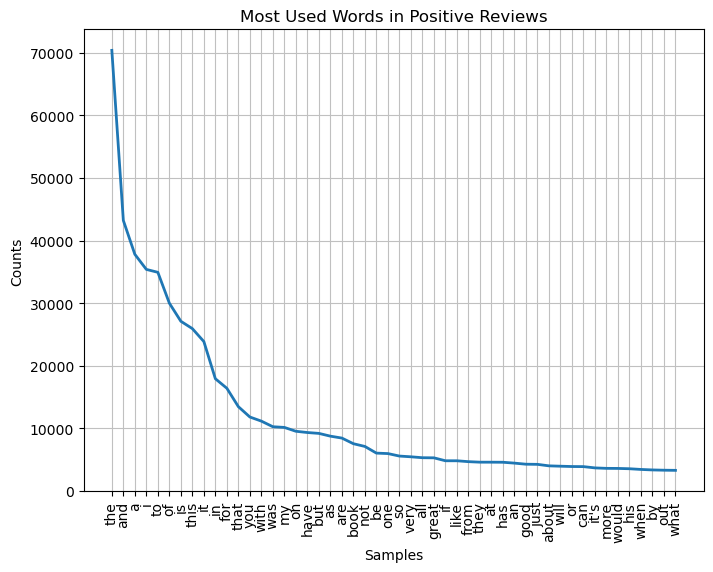

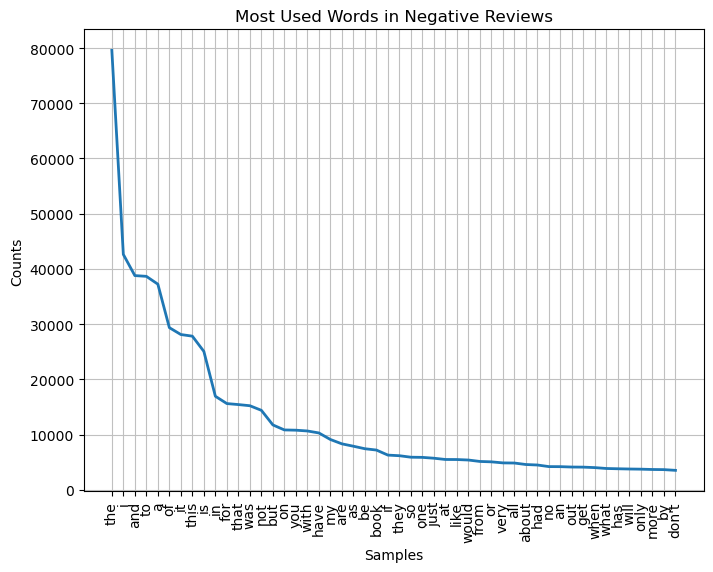

In [11]:
plt.subplots(figsize=(8,6))
plt.title("Most Used Words in Positive Reviews")
positiveFD.plot(50)
plt.show()

plt.subplots(figsize=(8,6))
plt.title("Most Used Words in Negative Reviews")
negativeFD.plot(50)
plt.show()

J'utilise la librairie NLTK afin de nettoyer la data pour chaque commentaire

In [12]:
cleanedData = []

lemma = WordNetLemmatizer()
swords = stopwords.words("english")
for text in data["review"]:

    text = re.sub(r'http\S+', '', text)
    text = re.sub("[^a-zA-Z0-9]"," ",text)
    
    text = nltk.word_tokenize(text.lower())
    text = [lemma.lemmatize(word) for word in text]

    text = [word for word in text if word not in swords]
    
    text = " ".join(text)
    
    cleanedData.append(text)

In [13]:
for i in range(0,5):
    print(cleanedData[i],end="\n\n")

looking mantra long time child yoga glad lotus mantra making class enjoyable recommended even adult motion lotusflower opening going back ground

little disapointed quality metal case cause thing saw wa photo web

purveyor exceptional mystery crime novel pleasant surprise find one random pick turning well parker ha uncanny grasp lifestyle orange county keen insight personality inhabitant naughton true crime noir treat parker personalization evokes dread main character feel highly recommended

walker percy ha written book never really answer question somehow leaf feeling broader understanding mean human witty sarcastic entertaining painfully honest wonderful book read anyone wishing understand human condition even sure describe get know mean read culture value class 10 year ago gone thru 5 coppies lending never getting back

glad bought wok best one owed ever easy clean throw dishwasher food sticking like little red dot tell wok hot never use another wok make sure use silicon stirring s

Je fais le sac de mots de mes commentaires.

In [14]:
vectorizer = CountVectorizer(max_features=10000)
BOW = vectorizer.fit_transform(cleanedData)

Implémenter les techniques de NLP et le modèle de ML ou DL choisi afin de
réaliser les prédictions nécessaires.

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(BOW,np.asarray(data["note"]))

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(30000, 10000)
(10000, 10000)
(30000,)
(10000,)


J'importe et je train le modèle SVC de scikit learn.

In [16]:
from sklearn.svm import SVC

model = SVC()
model.fit(x_train,y_train)

SVC()

In [17]:
predictions = model.predict(x_test)

Évaluer la performance de votre modèle.

Je calcul le taux d'accuracy de mon modèle.

In [21]:
from sklearn.metrics import accuracy_score

print("Accuracy of model is {}%".format(accuracy_score(y_test,predictions) * 100))

Accuracy of model is 84.35000000000001%


Les résultats montrent que notre modèle à 84% d'accuracy, ce qui n'est pas suffisant. Il se pourrait que des faux négatifs ou positifs se trouvent dans les 20 000 commentaires. Il faut analyser la data et enlever le plus possible de valeures extrêmes. Il serait aussi judicieux d'augmeneter le nombre de commentaires, mais mon pc n'est pas assez puissant et la limite de temps m'empêche de relancer une tentative.